# Earth scored planets
---
Earth-like Candidates Ranked by Similarity Score

In [307]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

In [308]:
# Load the dataset
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


### Scoring Criteria

Each planet is assigned a score based on its similarity to Earth across several key features.

The scoring is based on the following criteria:

- Planet radius (target: 1 Earth radius)
- Planet mass (target: 1 Earth mass)
- Orbital distance (target: 1 AU)
- Equilibrium temperature (target: ~ 255K, Earth-like conditions)
- Host star age (target: ~ 4.6 Gyr)
- Host star radius (target: 1 Solar radius)
- Host star mass (target: 1 Solar mass)

For each feature, the score is calculated based on the deviation from Earth's value. Smaller deviations result in higher similarity scores.

In [309]:
earth_like_scored_dataset = data.copy()

In [310]:
EARTH_RADIUS = 1
EARTH_MASS = 1
EARTH_DISTANCE = 1
EARTH_TEMP = 255
SUN_AGE = 4.6
SUN_RADIUS = 1
SUN_MASS = 1

In [311]:
features = [
    'planet_radius_earth',
    'planet_mass_earth',
    'semi_major_axis_au',
    'equilibrium_temp_k',
    'star_age_gyr',
    'star_radius_sun',
    'star_mass_sun'
]

earth_like_scored_dataset = data.dropna(subset=features).copy()
earth_like_scored_dataset

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
5,Kepler-280 c,Kepler-280,1,2,Transit,2014.0,Kepler,4.807091,2.010000,4.700000,...,291.390533,42.180473,0,Mini-Neptune,False,True,False,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6144,V1298 Tau d,V1298 Tau,3,4,Transit,2019.0,K2,12.401394,6.530000,6.000000,...,61.331654,20.157032,0,Gas Giant,False,True,False,Mid(100-500pc),K-type,Medium(10-100d)
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [312]:
def similarity(value, target):
    """
    Computes similarity score between a given value and a target reference.

    :param value: float or array-like
        The observed value of a planetary feature (radius, mass, temperature)

    :param target: float
        The reference Earth value for the corresponding feature

    :return: float or array-like
        A similarity score between 0 and 1, where:
        - 1 indicates identical to Earth
        - values closer to 0 indicate greater difference
    """
    return 1 / (1 + np.abs(value - target) / target)

In [313]:
# Feature Scoring
# In this step, each planetary and stellar characteristic is transformed into a similarity score relative to Earth (or the Sun for stellar properties).
# The `similarity()` function converts raw physical values into normalized scores between 0 and 1, allowing direct comparison across different features.

df = earth_like_scored_dataset

df['radius_score'] = similarity(df['planet_radius_earth'], EARTH_RADIUS)
df['mass_score'] = similarity(df['planet_mass_earth'], EARTH_MASS)
df['distance_score'] = similarity(df['semi_major_axis_au'], EARTH_DISTANCE)
df['temp_score'] = similarity(df['equilibrium_temp_k'], EARTH_TEMP)
df['star_age_score'] = similarity(df['star_age_gyr'], SUN_AGE)
df['star_radius_score'] = similarity(df['star_radius_sun'], SUN_RADIUS)
df['star_mass_score'] = similarity(df['star_mass_sun'], SUN_MASS)

In [314]:
# The weights are assigned based on domain knowledge,
# giving higher importance to planetary characteristics (mass, radius, temperature)
# compared to stellar properties.

weights = {
    'radius_score': 2,
    'mass_score': 2,
    'distance_score': 1.5,
    'temp_score': 2,
    'star_age_score': 1,
    'star_radius_score': 1,
    'star_mass_score': 1
}

The total score represents how similar each exoplanet is to Earth based on multiple key characteristics

- 1 - very similar to Earth
- 0 - very different from Earth

The final score is calculated as a weighted average of all individual scores:

$$ \Large
\text{Total Score} =
\frac{
(r_{score} \cdot w_r) +
(m_{score} \cdot w_m) +
(d_{score} \cdot w_d) +
(t_{score} \cdot w_t) +
(sa_{score} \cdot w_{sa}) +
(sr_{score} \cdot w_{sr}) +
(sm_{score} \cdot w_{sm})
}{
\sum w
}
$$

Where:

- $w$ - weight (represents how important each feature is in the total score calculation)

- $r$ - planet radius
- $m$ - planet mass
- $d$ - orbital distance
- $t$ - temperature
- $sa$ - star age
- $sr$ - star radius
- $sm$ - star mass

In [315]:
df['total_score'] = (
    df['radius_score'] * weights['radius_score'] +
    df['mass_score'] * weights['mass_score'] +
    df['distance_score'] * weights['distance_score'] +
    df['temp_score'] * weights['temp_score'] +
    df['star_age_score'] * weights['star_age_score'] +
    df['star_radius_score'] * weights['star_radius_score'] +
    df['star_mass_score'] * weights['star_mass_score']
) / sum(weights.values())

df['total_score'] = df['total_score'].round(2)

In [316]:
top_10_different_weights = df.sort_values('total_score', ascending=False).head(10)
top_10_different_weights

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,star_type,orbital_period_cat,radius_score,mass_score,distance_score,temp_score,star_age_score,star_radius_score,star_mass_score,total_score
3509,Kepler-1178 b,Kepler-1178,1,1,Transit,2016.0,Kepler,31.806340,1.070,1.240,...,K-type,Medium(10-100d),0.934579,0.806452,0.543360,0.674603,0.982906,0.800000,0.833333,0.79
3573,Kepler-1417 b,Kepler-1417,1,1,Transit,2016.0,Kepler,20.350521,1.000,0.972,...,G-type(Sun-like),Medium(10-100d),1.000000,0.972763,0.537814,0.366906,0.896686,0.980392,0.980392,0.79
3699,Kepler-1482 b,Kepler-1482,1,1,Transit,2016.0,Kepler,12.253832,1.010,1.010,...,G-type(Sun-like),Medium(10-100d),0.990099,0.990099,0.526227,0.376106,0.972516,0.862069,0.892857,0.78
586,Kepler-220 d,Kepler-220,1,4,Transit,2014.0,Kepler,28.122397,0.980,0.904,...,K-type,Medium(10-100d),0.980392,0.912409,0.544366,0.635910,0.766667,0.749625,0.786782,0.78
2612,TOI-700 e,TOI-700,1,4,Transit,2023.0,Transiting Exoplanet Survey Satellite (TESS),27.809780,0.953,0.818,...,M-type(Red Dwarf),Medium(10-100d),0.955110,0.846024,0.535906,0.934408,0.597403,0.633312,0.630915,0.77
5802,Kepler-438 b,Kepler-438,1,1,Transit,2015.0,Kepler,35.233190,1.120,1.460,...,K-type,Medium(10-100d),0.892857,0.684932,0.545256,0.885417,0.958333,0.675676,0.686813,0.77
5089,TOI-700 d,TOI-700,1,4,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),37.423960,1.073,1.250,...,M-type(Red Dwarf),Medium(10-100d),0.931966,0.800000,0.544455,0.948661,0.597403,0.633312,0.630915,0.77
3666,Kepler-1464 c,Kepler-1464,1,2,Transit,2016.0,Kepler,5.327863,1.000,0.972,...,G-type(Sun-like),Short(1-10d),1.000000,0.972763,0.515732,0.249267,0.866290,0.990099,0.980392,0.77
2598,Kepler-1328 b,Kepler-1328,1,1,Transit,2016.0,Kepler,4.521589,0.980,0.904,...,G-type(Sun-like),Short(1-10d),0.980392,0.912409,0.513347,0.210049,0.993521,0.990099,1.000000,0.76
1699,Kepler-1605 b,Kepler-1605,1,1,Transit,2016.0,Kepler,85.756550,1.080,1.280,...,G-type(Sun-like),Medium(10-100d),0.925926,0.781250,0.611872,0.482955,0.982906,0.847458,0.877193,0.76


In [317]:
# top_10_different_weights.to_csv('ds_1_earth_like_planets.csv', index=False)

Kepler-1417 b - https://science.nasa.gov/exoplanet-catalog/kepler-1417-b/

Kepler-1178 b - https://science.nasa.gov/exoplanet-catalog/kepler-1178-b/

Kepler-1482 b - https://science.nasa.gov/exoplanet-catalog/kepler-1482-b/

...

Interestingly, the two planets identified through strict filtering (L 98-59 e and L 98-59 f) do not appear in the top-ranked candidates based on the similarity score.

This highlights the difference between binary filtering and continuous scoring approaches.

While filtering applies strict thresholds, scoring evaluates overall similarity across multiple features, allowing other planets to rank higher despite not meeting all strict criteria.

In [318]:
df[df['planet_name'].isin(['L 98-59 e', 'L 98-59 f'])]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,star_type,orbital_period_cat,radius_score,mass_score,distance_score,temp_score,star_age_score,star_radius_score,star_mass_score,total_score
3913,L 98-59 e,L 98-59,1,5,Radial Velocity,2021.0,Multiple Observatories,12.8278,1.49,2.82,...,M-type(Red Dwarf),Medium(10-100d),0.671141,0.354610,0.518457,0.734870,0.931174,0.593648,0.585583,0.61
3914,L 98-59 f,L 98-59,1,5,Radial Velocity,2025.0,Multiple Facilities,23.0640,1.48,2.80,...,M-type(Red Dwarf),Medium(10-100d),0.675676,0.357143,0.527760,0.894737,0.931174,0.593648,0.585583,0.64


To evaluate the impact of the weighting scheme on the ranking results, an alternative scoring configuration with equal weights was applied.

This allows us to assess whether the ranking is strongly dependent on the chosen weights or remains stable across different assumptions.

In [319]:
# Equal Weights Scoring

# In this step, all features are assigned equal importance in the scoring process.

# This provides a baseline for comparison, allowing us to evaluate how sensitive the ranking is to the choice of weights.

equal_weights = {
    'radius_score': 1,
    'mass_score': 1,
    'distance_score': 1,
    'temp_score': 1,
    'star_age_score': 1,
    'star_radius_score': 1,
    'star_mass_score': 1
}

In [320]:
# Weighted Earth Similarity Score
df['total_score'] = (
    df['radius_score'] * equal_weights['radius_score'] +
    df['mass_score'] * equal_weights['mass_score'] +
    df['distance_score'] * equal_weights['distance_score'] +
    df['temp_score'] * equal_weights['temp_score'] +
    df['star_age_score'] * equal_weights['star_age_score'] +
    df['star_radius_score'] * equal_weights['star_radius_score'] +
    df['star_mass_score'] * equal_weights['star_mass_score']
) / sum(equal_weights.values())

df['total_score'] = df['total_score'].round(2)

In [321]:
top_10_equal_weights = df.sort_values('total_score', ascending=False).head(10)
top_10_equal_weights

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,star_type,orbital_period_cat,radius_score,mass_score,distance_score,temp_score,star_age_score,star_radius_score,star_mass_score,total_score
3573,Kepler-1417 b,Kepler-1417,1,1,Transit,2016.0,Kepler,20.350521,1.00,0.972,...,G-type(Sun-like),Medium(10-100d),1.000000,0.972763,0.537814,0.366906,0.896686,0.980392,0.980392,0.82
3666,Kepler-1464 c,Kepler-1464,1,2,Transit,2016.0,Kepler,5.327863,1.00,0.972,...,G-type(Sun-like),Short(1-10d),1.000000,0.972763,0.515732,0.249267,0.866290,0.990099,0.980392,0.80
2598,Kepler-1328 b,Kepler-1328,1,1,Transit,2016.0,Kepler,4.521589,0.98,0.904,...,G-type(Sun-like),Short(1-10d),0.980392,0.912409,0.513347,0.210049,0.993521,0.990099,1.000000,0.80
3509,Kepler-1178 b,Kepler-1178,1,1,Transit,2016.0,Kepler,31.806340,1.07,1.240,...,K-type,Medium(10-100d),0.934579,0.806452,0.543360,0.674603,0.982906,0.800000,0.833333,0.80
3699,Kepler-1482 b,Kepler-1482,1,1,Transit,2016.0,Kepler,12.253832,1.01,1.010,...,G-type(Sun-like),Medium(10-100d),0.990099,0.990099,0.526227,0.376106,0.972516,0.862069,0.892857,0.80
3417,Kepler-1376 b,Kepler-1376,1,1,Transit,2016.0,Kepler,5.308807,1.05,1.160,...,G-type(Sun-like),Short(1-10d),0.952381,0.862069,0.515411,0.244722,0.982906,0.970874,0.980392,0.79
3664,Kepler-1612 b,Kepler-1612,1,1,Transit,2016.0,Kepler,3.917951,1.03,1.080,...,G-type(Sun-like),Short(1-10d),0.970874,0.925926,0.512348,0.247573,0.993521,0.943396,0.961538,0.79
3589,Kepler-132 e,Kepler-132,2,4,Transit,2016.0,Kepler,110.286937,1.18,1.760,...,F-type,Long(100-365d),0.847458,0.568182,0.640726,0.615942,0.952381,0.909091,0.970874,0.79
1699,Kepler-1605 b,Kepler-1605,1,1,Transit,2016.0,Kepler,85.756550,1.08,1.280,...,G-type(Sun-like),Medium(10-100d),0.925926,0.781250,0.611872,0.482955,0.982906,0.847458,0.877193,0.79
5887,Kepler-1425 b,Kepler-1425,1,1,Transit,2016.0,Kepler,14.454130,0.94,0.779,...,G-type(Sun-like),Medium(10-100d),0.943396,0.819001,0.530321,0.377219,0.896686,0.952381,0.970874,0.78


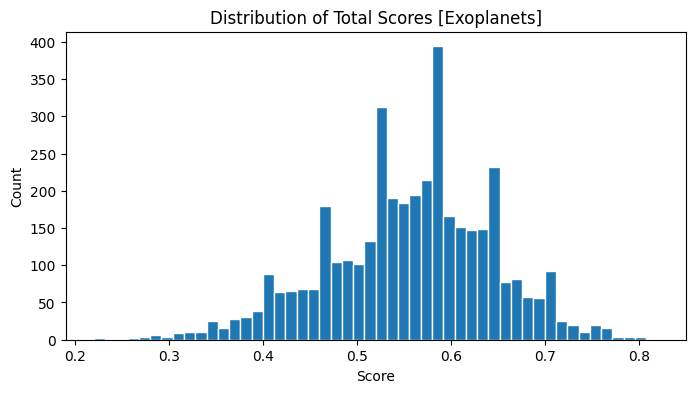

In [322]:
plt.figure(figsize=(8,4))
plt.hist(df['total_score'], bins=50, edgecolor='white')

plt.title('Distribution of Total Scores [Exoplanets]')
plt.xlabel('Score')
plt.ylabel('Count')

plt.show()

## Distribution of Total Scores

The histogram shows the distribution of total similarity scores across all analyzed exoplanets.

Most planets are concentrated in the range **0.5 – 0.65**, forming a clear peak around **~0.58–0.60**.
This indicates that the majority of exoplanets have a **moderate similarity to Earth**, but not extremely high.

Very high scores (**> 0.7**) are rare, suggesting that planets highly similar to Earth are uncommon in the dataset.
Similarly, very low scores (< 0.4) are also less frequent, meaning most planets are not extremely different either.

---

## Key Insights

- The distribution is approximately **normal (bell-shaped)**
- Most planets fall into a **mid-similarity zone**
- **Top Earth-like candidates are outliers**, not the norm
- There is **no large cluster near 1**, meaning no perfect Earth analog exists in the data

---

## Conclusion

This distribution confirms that Earth-like conditions are relatively rare.

While many planets share some similarities with Earth, only a small subset meets multiple criteria simultaneously.
This supports the idea that **habitability is a multi-factor problem**, where high similarity requires alignment across several independent features.

## Note

In this analysis, we define "life" based on conditions known from Earth, such as the presence of liquid water, suitable temperature, and Earth-like planetary characteristics.

However, this definition is inherently limited.

It is scientifically possible that life may exist in forms fundamentally different from those on Earth. Such life could potentially thrive under extreme conditions, similar to extremophiles found on Earth — for example, organisms living in volcanic environments or beneath polar ice.

Therefore, while this model identifies Earth-like planets, it does not exclude the possibility of life existing under entirely different conditions.